In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from pm.utils.data import DataManager

from utils.components import (
    download_all_macro_factors,
    transform_macro_factors,
    calculate_all_spreads,
    align_to_portfolio,
    download_macro_factors
)

from utils.analyzers import (
    MacroFactorAnalyzer,
    MacroCorrelationAnalyzer,
    MacroSensitivityAnalyzer,
    MacroSituationAnalyzer
)

from utils.reporters import (
    MacroFactorReporter,
    MacroCorrelationReporter,
    MacroSensitivityReporter,
    MacroSituationReporter
)

from utils.tools import (
    MACRO_CORE_FACTORS,
    MACRO_GLOBAL_FACTORS,
    FACTORS_TO_USE,
)

In [2]:
factor_analyzer = MacroFactorAnalyzer(annual_factor=252)
factor_reporter = MacroFactorReporter(factor_analyzer)
corr_analyzer = MacroCorrelationAnalyzer(max_lag=126)
corr_reporter = MacroCorrelationReporter(corr_analyzer)
sens_analyzer = MacroSensitivityAnalyzer(annual_factor=252)
sens_reporter = MacroSensitivityReporter(sens_analyzer)
situation_analyzer = MacroSituationAnalyzer()
situation_reporter = MacroSituationReporter(situation_analyzer)


In [3]:
TICKERS = ["META", "AAPL", "GOOGL", "NVDA", "MSFT"]
WEIGHTS = np.ones(len(TICKERS)) / len(TICKERS)
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"
FACTORS_TO_USE = FACTORS_TO_USE

In [4]:
data_manager = DataManager()
assets_prices, _ = data_manager.download_portfolio_with_benchmark(
    tickers=TICKERS,
    benchmark_name="SP500",
    start_date=START_DATE,
    end_date=END_DATE
)

returns = assets_prices.pct_change().dropna()
portfolio_returns = (returns * WEIGHTS).sum(axis=1)

Descargando portafolio completo...
Período: 2020-01-01 → 2024-12-31


[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed

Período: 2020-01-01 → 2024-12-31
Portafolio descargado: 5 activos + benchmark


In [5]:
factors_raw = download_macro_factors(
    factor_names=FACTORS_TO_USE,
    start_date=START_DATE,
    end_date=END_DATE,
    progress=True
)

[*********************100%***********************]  11 of 11 completed


In [6]:
factors_dict, factors_df = transform_macro_factors(
    factors_raw,
    target_index=portfolio_returns.index
)

[Macro] OIL: 1 valores <= 0 encontrados, reemplazados por NaN


In [7]:
spreads_df = calculate_all_spreads(factors_df)

if not spreads_df.empty:
    print(f"Spreads calculados: {spreads_df.shape[1]}")
    print(f"   {', '.join(spreads_df.columns)}")

    factors_complete = pd.concat([factors_df, spreads_df], axis=1)
else:
    print("No hay spreads calculados (factores faltantes)")
    factors_complete = factors_df.copy()

Spreads calculados: 3
   yield_curve_30_10y, credit_spread_hy, credit_spread_hy_lqd


In [8]:
factors_aligned = align_to_portfolio(factors_complete, portfolio_returns)

In [9]:
factor_results = factor_analyzer.analyze(
    portfolio_returns,
    factors_aligned.dropna(),
    use_hac=True
)

factor_reporter.print_analysis(factor_results)

                      ANÁLISIS DE FACTORES MACRO                      
RESUMEN DE REGRESIÓN
  Alpha (diario):             0.0580%
  Alpha (anual):               15.72%
  R²:                          0.756
  R² ajustado:                 0.754
  Observaciones:                1256
  Interpretación:           Excelente - genera alpha significativo
FACTOR LOADINGS (BETAS)
Factor                     Beta     t-stat    p-value Signif    
SP500                    1.6046     17.385     0.0000 ***       
HYG                     -0.2279     -4.178     0.0000 ***       
credit_spread_hy        -0.2223     -5.519     0.0000 ***       
yield_curve_30_10y       0.1354      1.021     0.3075           
LQD                     -0.1307     -4.346     0.0000 ***       
credit_spread_hy_lqd    -0.0972     -1.563     0.1181           
RATE_30Y                 0.0942      0.858     0.3911           
DXY                      0.0497      0.506     0.6129           
RATE_10Y                -0.0412     -0.550   

In [10]:
corr_results = corr_analyzer.analyze(
    portfolio_returns,
    factors_aligned.dropna()
)

corr_reporter.print_analysis(corr_results)

                   ANÁLISIS DE CORRELACIONES MACRO                    
MEJORES CORRELACIONES (con lag óptimo)
Factor                   Corr    Lag     t-stat    p-value
SP500                   0.860      0     23.807     0.0000
VIX                    -0.644      0    -16.986     0.0000
HYG                     0.637      0     10.124     0.0000
credit_spread_hy        0.402      0      7.962     0.0000
credit_spread_hy_lqd    0.345      0      6.432     0.0000
LQD                     0.304      0      4.503     0.0000
DXY                    -0.181      0     -3.726     0.0002
OIL                     0.158      0      3.406     0.0007
GOLD                    0.109      0      2.779     0.0055
GOVT_20Y               -0.099      9     -2.427     0.0152
FACTORES LAGGING (siguen al portafolio)
  • GOVT_20Y: 9 días retrasado (corr=-0.099)
  • RATE_30Y: 36 días retrasado (corr=0.084)
  • RATE_10Y: 41 días retrasado (corr=-0.082)
  • RATE_2Y: 125 días retrasado (corr=0.046)


In [11]:
sens_results = sens_analyzer.analyze(
    portfolio_returns,
    factors_aligned.dropna()
)

sens_reporter.print_analysis(sens_results)

                   ANÁLISIS DE SENSIBILIDADES MACRO                   
EXPOSICIONES POR MAGNITUD
ALTA EXPOSICIÓN (|β| > 0.5)
  ↑ SP500: β =   1.605
EXPOSICIÓN MODERADA (0.2 ≤ |β| ≤ 0.5)
  ↓ HYG: β =  -0.228
  ↓ credit_spread_hy: β =  -0.222
BAJA EXPOSICIÓN (|β| < 0.2)
    yield_curve_30_10y: β =   0.135
    LQD: β =  -0.131
    credit_spread_hy_lqd: β =  -0.097
    RATE_30Y: β =   0.094
    DXY: β =   0.050
FACTOR DOMINANTE
  SP500: β = 1.605
  Interpretación: Exposición muy alta


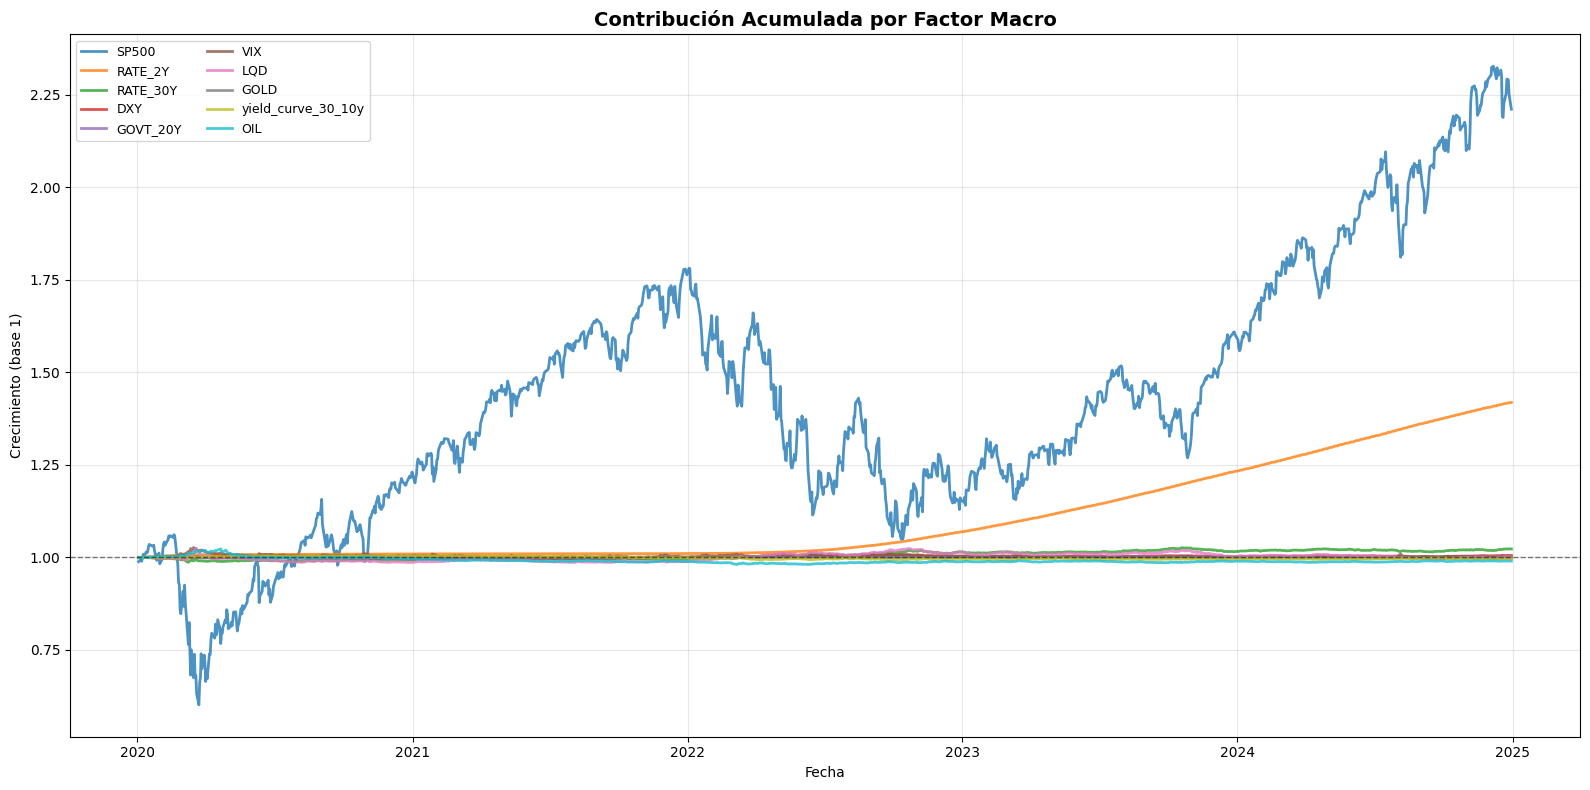


=== Valores Finales de Contribución Acumulada ===
SP500: 2.2116
RATE_2Y: 1.4190
RATE_30Y: 1.0229
DXY: 1.0055
GOVT_20Y: 1.0018
VIX: 1.0014
LQD: 1.0012
GOLD: 0.9983
yield_curve_30_10y: 0.9967
OIL: 0.9901


In [12]:
factor_contrib = factor_results['factor_contributions']

fig, ax = plt.subplots(figsize=(16, 8))

contrib_df = pd.DataFrame(factor_contrib).fillna(0).replace([np.inf, -np.inf], 0)

# Limitar valores extremos por seguridad
contrib_df = contrib_df.clip(lower=-0.1, upper=0.1)

# Calcular producto acumulado
contrib_cumsum = (1 + contrib_df).cumprod()

# Filtrar factores con contribución significativa
plot_cols = [col for col in contrib_cumsum.columns 
             if col not in ['alpha', 'residual'] 
             and contrib_cumsum[col].abs().max() > 0.01
             and contrib_cumsum[col].abs().max() < 100]

# Ordenar por contribución acumulada final
if plot_cols:
    final_values = contrib_cumsum[plot_cols].iloc[-1].abs()
    plot_cols = final_values.sort_values(ascending=False).head(10).index.tolist()

for col in plot_cols:
    ax.plot(contrib_cumsum.index, contrib_cumsum[col], label=col, linewidth=2, alpha=0.8)

ax.set_title('Contribución Acumulada por Factor Macro', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Crecimiento (base 1)')
ax.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.legend(loc='best', ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)

try:
    plt.tight_layout()
except:
    pass

plt.show()

# Mostrar valores finales
print("\n=== Valores Finales de Contribución Acumulada ===")
for col in plot_cols:
    final_val = contrib_cumsum[col].iloc[-1]
    print(f"{col}: {final_val:.4f}")

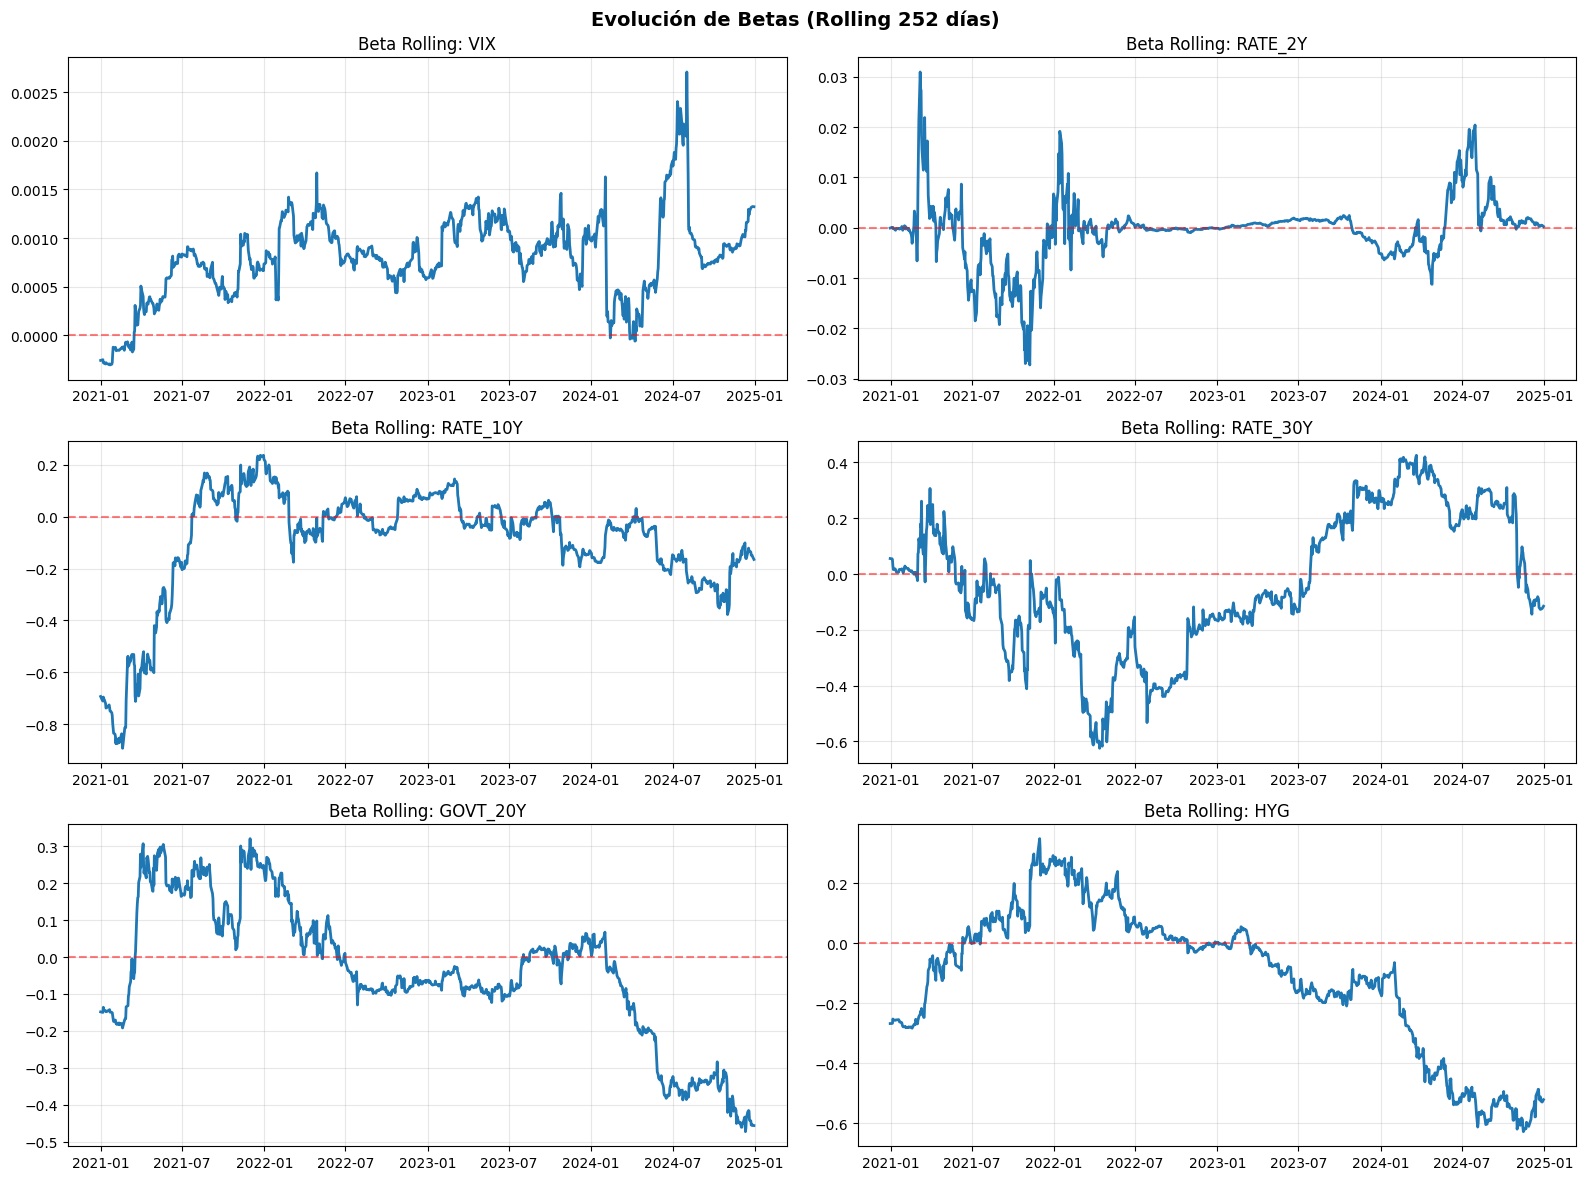

In [13]:
rolling_betas = sens_analyzer.analyze_rolling(
    portfolio_returns,
    factors_aligned.dropna(),
    window=252
)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

beta_cols = [col for col in rolling_betas.columns if col.startswith('beta_')]

for i, col in enumerate(beta_cols[:6]):
    factor_name = col.replace('beta_', '')
    axes[i].plot(rolling_betas.index, rolling_betas[col], linewidth=2)
    axes[i].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(f'Beta Rolling: {factor_name}')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Evolución de Betas (Rolling 252 días)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
global_factors = download_macro_factors(
    MACRO_GLOBAL_FACTORS,
    START_DATE,
    END_DATE,
    progress=True
)

situation_results = situation_analyzer.analyze(global_factors)
situation_reporter.print_situation(situation_results)


[*********************100%***********************]  20 of 20 completed


                        SITUACIÓN MACROECONÓMICA GLOBAL                         
RESUMEN EJECUTIVO

  Nivel de riesgo global: 🟢 BAJO

  ✅ No se detectan factores de riesgo significativos
CURVA DE TIPOS DE INTERÉS (USA)

  Niveles actuales:
     10Y:   4.55%
      2Y:   4.18%
     30Y:   4.76%
      5Y:   4.37%

  Spreads:
    🟢     10Y-2Y:  +0.36 pp
    🟢     10Y-5Y:  +0.18 pp
    🟢    30Y-10Y:  +0.22 pp

  💡 NORMAL - Crecimiento estable
SEÑALES DE INFLACIÓN (Commodities)

  Cambio últimos 12 meses:
    🔴 Oro         :  +26.36%
    🔴 Plata       :  +22.02%
    🟢 Petróleo    :   -0.92%
    🟢 Cobre       :   +4.25%

  💡 MODERADA - Inflación controlada
     Cambio promedio: +12.93%
CONDICIONES DE CRÉDITO Y VOLATILIDAD

  🟢 VIX (volatilidad):        17.40

  💡 NORMAL - Volatilidad controlada

  Niveles ETFs crédito:
    HYG (High Yield):        $  74.26
    LQD (Investment Grade):  $ 102.38
BONOS SOBERANOS GLOBALES
{'Región':<15} {'Nivel':<12} {'1 Mes':<12} {'1 Año':<12}
  Alemania        